In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import interpolate
import os

In [2]:
with open("/glade/u/home/advike/edc3deuttemp2007.txt", "r") as f:
    for i, line in enumerate(f):
        print(line, end="")
        if i > 50:
            break

EPICA Dome C Ice Core 800KYr Deuterium Data and Temperature Estimates
-----------------------------------------------------------------------
               World Data Center for Paleoclimatology, Boulder
                                  and
                     NOAA Paleoclimatology Program
-----------------------------------------------------------------------
NOTE: PLEASE CITE CONTRIBUTORS WHEN USING THIS DATA!!!!!


NAME OF DATA SET: 
EPICA Dome C Ice Core 800KYr Deuterium Data and Temperature Estimates

LAST UPDATE: 11/26/2007 (Replaced age model. This file now includes EDC3 
age model.  Previous version of this file dated 10/16/2007 erroneously 
included the older EDC1-EDC2 age model)

CONTRIBUTOR: Valérie Masson-Delmotte, LSCE/IPSL 
IGBP PAGES/WDCA CONTRIBUTION SERIES NUMBER: 2007-091

SUGGESTED DATA CITATION: Jouzel, J., et al.  2007.
EPICA Dome C Ice Core 800KYr Deuterium Data and Temperature Estimates. 
IGBP PAGES/World Data Center for Paleoclimatology 
Data Contribution Ser

In [3]:
with open("/glade/u/home/advike/edc3deuttemp2007.txt", "r") as f:
    for i, line in enumerate(f):
        print(f"{i}: {line}", end="")
        if i > 90:
            break

0: EPICA Dome C Ice Core 800KYr Deuterium Data and Temperature Estimates
1: -----------------------------------------------------------------------
2:                World Data Center for Paleoclimatology, Boulder
3:                                   and
4:                      NOAA Paleoclimatology Program
5: -----------------------------------------------------------------------
6: NOTE: PLEASE CITE CONTRIBUTORS WHEN USING THIS DATA!!!!!
7: 
8: 
9: NAME OF DATA SET: 
10: EPICA Dome C Ice Core 800KYr Deuterium Data and Temperature Estimates
11: 
12: LAST UPDATE: 11/26/2007 (Replaced age model. This file now includes EDC3 
13: age model.  Previous version of this file dated 10/16/2007 erroneously 
14: included the older EDC1-EDC2 age model)
15: 
16: CONTRIBUTOR: Valérie Masson-Delmotte, LSCE/IPSL 
17: IGBP PAGES/WDCA CONTRIBUTION SERIES NUMBER: 2007-091
18: 
19: SUGGESTED DATA CITATION: Jouzel, J., et al.  2007.
20: EPICA Dome C Ice Core 800KYr Deuterium Data and Temperature Estimates.

In [5]:
edc = pd.read_csv("/glade/u/home/advike/edc3deuttemp2007.txt", 
                  skiprows=92,  # skip one more row to skip the header
                  sep='\s+',
                  names=["bag", "depth", "age", "dD", "temp"])

# Convert to numeric
edc = edc.apply(pd.to_numeric, errors='coerce')

# Drop rows with NaN age
edc = edc.dropna(subset=["age"])

print(edc.head(10))
print(f"\nShape: {edc.shape}")
print(f"Age range: {edc['age'].min():.0f} to {edc['age'].max():.0f} years BP")
print(f"Temp range: {edc['temp'].min():.2f} to {edc['temp'].max():.2f} °C")

   bag  depth       age  dD  temp
0    1   0.00 -50.00000 NaN   NaN
1    2   0.55 -43.54769 NaN   NaN
2    3   1.10 -37.41829 NaN   NaN
3    4   1.65 -31.61153 NaN   NaN
4    5   2.20 -24.51395 NaN   NaN
5    6   2.75 -17.73776 NaN   NaN
6    7   3.30 -10.95945 NaN   NaN
7    8   3.85  -3.20879 NaN   NaN
8    9   4.40   5.48176 NaN   NaN
9   10   4.95  13.52038 NaN   NaN

Shape: (5800, 5)
Age range: -50 to 801662 years BP
Temp range: -10.58 to 5.46 °C


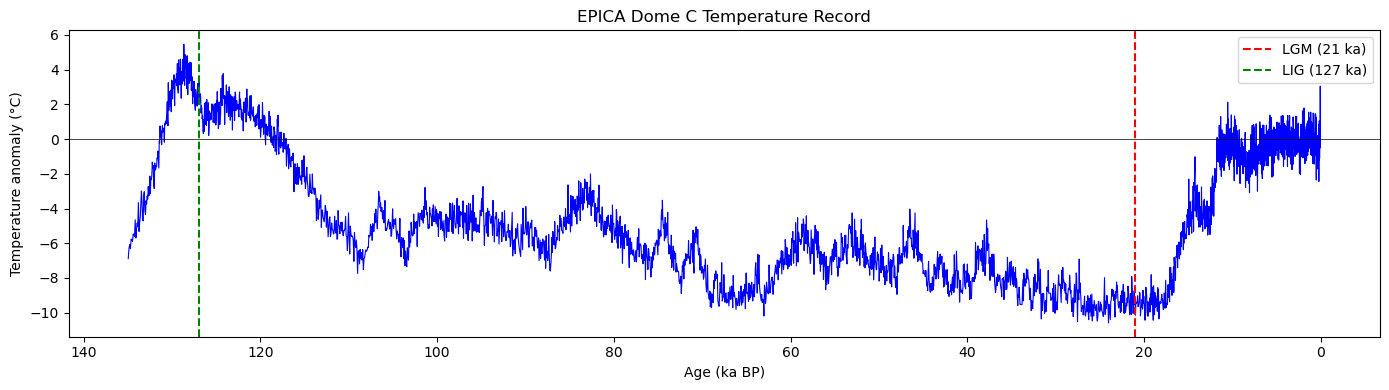

Temperature near LGM (21 ka):
            age   temp
915  20025.9492  -9.04
916  20071.9766  -9.46
917  20117.7188  -8.71
918  20163.3516  -9.79
919  20210.3184  -9.22
920  20257.0957  -9.53
921  20304.3652  -9.69
922  20352.4238  -9.72
923  20401.0352 -10.18
924  20450.2090  -8.92
925  20495.9707  -8.83
926  20540.7070  -9.31
927  20587.1621  -9.49
928  20634.5605  -9.65
929  20682.7129  -9.64
930  20730.7422  -9.03
931  20776.4121  -9.36
932  20823.2305  -9.41
933  20870.3926  -9.47
934  20917.7539  -9.39
935  20965.4648 -10.14
936  21014.8594  -9.25
937  21062.2578  -9.52
938  21109.1543  -8.74
939  21154.6133  -9.06
940  21201.1387 -10.02
941  21250.2695 -10.04
942  21299.6152  -9.20
943  21346.3184  -8.59
944  21390.1914  -7.92
945  21434.5781 -10.10
946  21482.3066  -9.71
947  21530.7148  -8.90
948  21577.6777  -9.64
949  21625.9883 -10.12
950  21675.7695  -9.57
951  21724.0586  -8.96
952  21770.1602  -8.72
953  21814.9258  -8.47
954  21859.1855  -9.42
955  21906.5254  -9.14
956 

In [6]:
# Filter to our time period of interest: 0 to 130,000 years BP
edc_plot = edc[(edc['age'] >= 0) & (edc['age'] <= 135000)].dropna(subset=['temp'])

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(edc_plot['age'] / 1000, edc_plot['temp'], 'b-', linewidth=0.8)
ax.axvline(x=21, color='r', linestyle='--', label='LGM (21 ka)')
ax.axvline(x=127, color='g', linestyle='--', label='LIG (127 ka)')
ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax.set_xlabel('Age (ka BP)')
ax.set_ylabel('Temperature anomaly (°C)')
ax.set_title('EPICA Dome C Temperature Record')
ax.legend()
ax.invert_xaxis()  # present day on right
plt.tight_layout()
plt.savefig('EDC_temperature_record.png', dpi=150)
plt.show()

# Print values near key time periods
print("Temperature near LGM (21 ka):")
print(edc[(edc['age'] > 20000) & (edc['age'] < 22000)][['age', 'temp']])
print("\nTemperature near LIG (127 ka):")
print(edc[(edc['age'] > 125000) & (edc['age'] < 129000)][['age', 'temp']])
print("\nTemperature near present (0-1 ka):")
print(edc[(edc['age'] >= 0) & (edc['age'] < 1000)][['age', 'temp']])

In [7]:
# Define anchor point temperature anomalies
# Take means over the characteristic periods
temp_PD  = edc[(edc['age'] >= 0) & (edc['age'] <= 1000)]['temp'].mean()
temp_LGM = edc[(edc['age'] >= 19000) & (edc['age'] <= 23000)]['temp'].mean()
temp_LIG = edc[(edc['age'] >= 120000) & (edc['age'] <= 130000)]['temp'].mean()

print(f"Present day temp anomaly:  {temp_PD:.2f} °C")
print(f"LGM temp anomaly:          {temp_LGM:.2f} °C")
print(f"LIG temp anomaly:          {temp_LIG:.2f} °C")

# Also find the LIG peak
lig_data = edc[(edc['age'] >= 115000) & (edc['age'] <= 135000)].dropna(subset=['temp'])
print(f"\nLIG peak temp anomaly: {lig_data['temp'].max():.2f} °C at age {lig_data.loc[lig_data['temp'].idxmax(), 'age']:.0f} BP")

Present day temp anomaly:  -0.15 °C
LGM temp anomaly:          -9.39 °C
LIG temp anomaly:          2.28 °C

LIG peak temp anomaly: 5.46 °C at age 128662 BP


Number of time slices: 255
Time range: 0 to 127000 BP
Max weight sum deviation from 1: 0.0


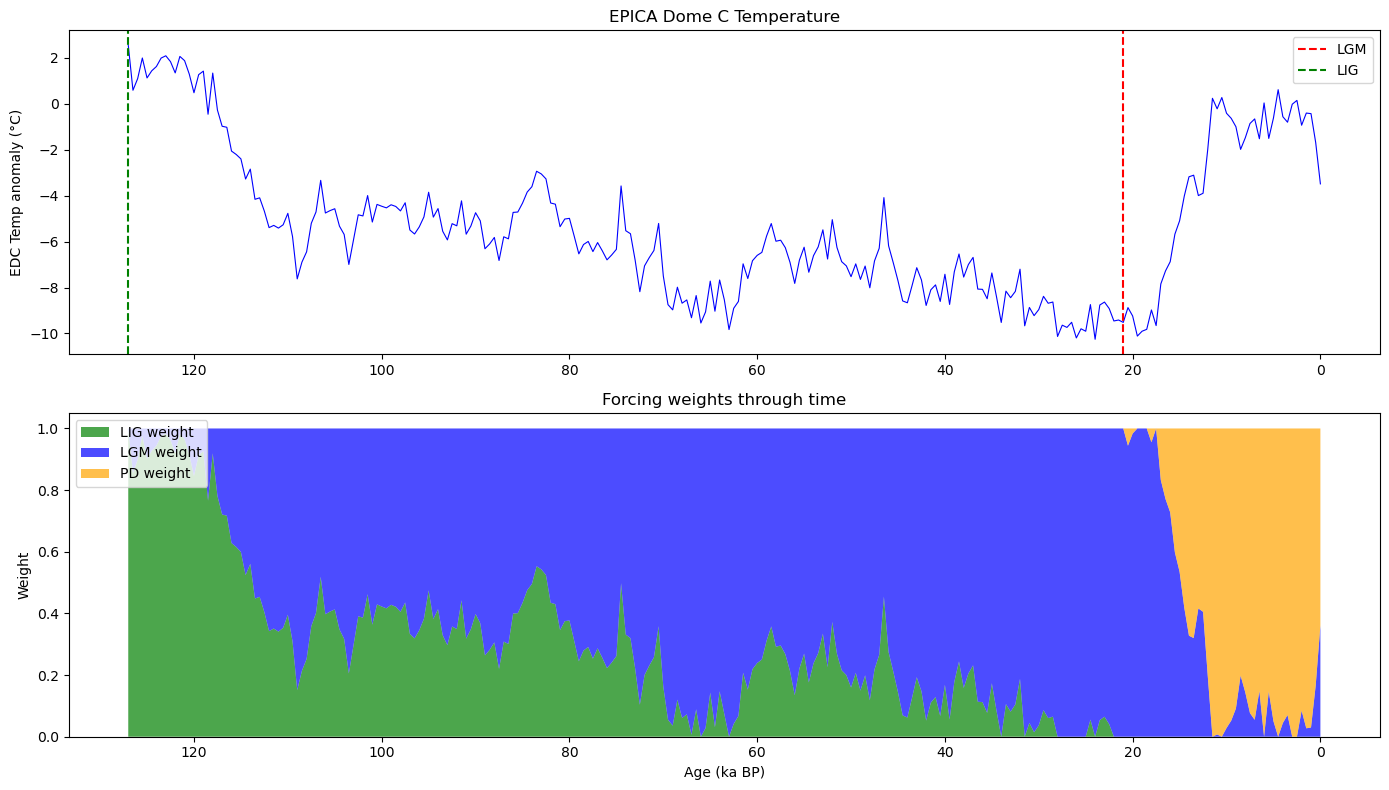

In [9]:
# Anchor values
temp_PD  = -0.15
temp_LGM = -9.39
temp_LIG =  2.28

# Create 500-year time slices from 127ka to 0ka
time_slices = np.arange(127000, -500, -500)  # 127000, 126500, ..., 500, 0
print(f"Number of time slices: {len(time_slices)}")
print(f"Time range: {time_slices[-1]} to {time_slices[0]} BP")

# Interpolate EDC temperature onto our time slices
edc_valid = edc[(edc['age'] >= 0) & (edc['age'] <= 130000)].dropna(subset=['temp'])
edc_interp = interpolate.interp1d(edc_valid['age'], edc_valid['temp'], 
                                   kind='linear', bounds_error=False, 
                                   fill_value='extrapolate')

edc_on_slices = edc_interp(time_slices)

# Compute weights for each time slice
weights_LGM = np.zeros(len(time_slices))
weights_LIG = np.zeros(len(time_slices))
weights_PD  = np.zeros(len(time_slices))

for i, (age, temp) in enumerate(zip(time_slices, edc_on_slices)):
    if age >= 21000:
        # LIG to LGM segment: interpolate between LIG and LGM
        alpha = (temp - temp_LIG) / (temp_LGM - temp_LIG)
        alpha = np.clip(alpha, 0, 1)
        weights_LGM[i] = alpha
        weights_LIG[i] = 1 - alpha
        weights_PD[i]  = 0
    else:
        # LGM to PD segment: interpolate between LGM and PD
        alpha = (temp - temp_LGM) / (temp_PD - temp_LGM)
        alpha = np.clip(alpha, 0, 1)
        weights_PD[i]  = alpha
        weights_LGM[i] = 1 - alpha
        weights_LIG[i] = 0

# Verify weights sum to 1
print("Max weight sum deviation from 1:", np.abs(weights_LGM + weights_LIG + weights_PD - 1).max())

# Plot weights through time
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(time_slices/1000, edc_on_slices, 'b-', linewidth=0.8)
axes[0].axvline(x=21, color='r', linestyle='--', label='LGM')
axes[0].axvline(x=127, color='g', linestyle='--', label='LIG')
axes[0].set_ylabel('EDC Temp anomaly (°C)')
axes[0].set_title('EPICA Dome C Temperature')
axes[0].legend()
axes[0].invert_xaxis()

axes[1].stackplot(time_slices/1000, weights_LIG, weights_LGM, weights_PD,
                  labels=['LIG weight', 'LGM weight', 'PD weight'],
                  colors=['green', 'blue', 'orange'], alpha=0.7)
axes[1].set_xlabel('Age (ka BP)')
axes[1].set_ylabel('Weight')
axes[1].set_title('Forcing weights through time')
axes[1].legend(loc='upper left')
axes[1].invert_xaxis()

plt.tight_layout()
plt.savefig('EDC_weights.png', dpi=150)
plt.show()

In [11]:
# Load end member forcing files
ref_pd  = xr.open_dataset("/glade/campaign/cesm/development/liwg/forAdvik/CISM3_initialization_AIS_08000.b_h_s_interp_median.m1for0bed.2025-03-03.nc", decode_cf=False)
lgm_forcing = xr.open_dataset("/glade/u/home/advike/CESM_Regrid/CISM3_initialization_AIS_08000.lgm21ka.nc", decode_cf=False)
lig_forcing = xr.open_dataset("/glade/u/home/advike/CESM_Regrid/CISM3_initialization_AIS_08000.lig127ka.nc", decode_cf=False)

print("PD artm range:", float(ref_pd["artm"].min()), "to", float(ref_pd["artm"].max()))
print("LGM artm range:", float(lgm_forcing["artm"].min()), "to", float(lgm_forcing["artm"].max()))
print("LIG artm range:", float(lig_forcing["artm"].min()), "to", float(lig_forcing["artm"].max()))

PD artm range: -58.074554443359375 to 7.778583526611328
LGM artm range: -65.31489562988281 to 2.122213840484619
LIG artm range: -58.17274475097656 to 8.064350128173828


In [12]:
# Extract 2D arrays for each end member (squeeze out time dimension)
pd_artm  = ref_pd["artm"].isel(time=0).values
pd_smb   = ref_pd["smb"].isel(time=0).values
pd_tf    = ref_pd["thermal_forcing"].isel(time=0).values

lgm_artm = lgm_forcing["artm"].isel(time=0).values
lgm_smb  = lgm_forcing["smb"].isel(time=0).values
lgm_tf   = lgm_forcing["thermal_forcing"].isel(time=0).values

lig_artm = lig_forcing["artm"].isel(time=0).values
lig_smb  = lig_forcing["smb"].isel(time=0).values
lig_tf   = lig_forcing["thermal_forcing"].isel(time=0).values

# Mask PD fill values
pd_smb = np.where(np.abs(pd_smb) > 1e6, np.nan, pd_smb)
pd_artm = np.where(pd_artm == -99999, np.nan, pd_artm)

# Handle TF fill values
pd_tf  = np.where(pd_tf  == -99999, np.nan, pd_tf)
lgm_tf = np.where(lgm_tf == -99999, np.nan, lgm_tf)
lig_tf = np.where(lig_tf == -99999, np.nan, lig_tf)

print("End members loaded successfully")
print(f"artm shapes: PD={pd_artm.shape}, LGM={lgm_artm.shape}, LIG={lig_artm.shape}")
print(f"tf shapes:   PD={pd_tf.shape},   LGM={lgm_tf.shape},   LIG={lig_tf.shape}")

End members loaded successfully
artm shapes: PD=(761, 761), LGM=(761, 761), LIG=(761, 761)
tf shapes:   PD=(30, 761, 761),   LGM=(30, 761, 761),   LIG=(30, 761, 761)


In [13]:
# Pre-allocate output arrays (time, y, x) and (time, zocn, y, x)
n_times = len(time_slices)
ny, nx = pd_artm.shape
nz = pd_tf.shape[0]

artm_out = np.zeros((n_times, ny, nx), dtype="float32")
smb_out  = np.zeros((n_times, ny, nx), dtype="float32")
tf_out   = np.zeros((n_times, nz, ny, nx), dtype="float32")

for i in range(n_times):
    w_pd  = weights_PD[i]
    w_lgm = weights_LGM[i]
    w_lig = weights_LIG[i]

    # artm — use nansum to handle NaNs in PD
    artm_out[i] = (w_pd  * np.nan_to_num(pd_artm,  nan=0.0) +
                   w_lgm * np.nan_to_num(lgm_artm, nan=0.0) +
                   w_lig * np.nan_to_num(lig_artm, nan=0.0))

    # smb
    smb_out[i]  = (w_pd  * np.nan_to_num(pd_smb,  nan=0.0) +
                   w_lgm * np.nan_to_num(lgm_smb, nan=0.0) +
                   w_lig * np.nan_to_num(lig_smb, nan=0.0))

    # thermal forcing
    tf_out[i]   = (w_pd  * np.nan_to_num(pd_tf,  nan=0.0) +
                   w_lgm * np.nan_to_num(lgm_tf, nan=0.0) +
                   w_lig * np.nan_to_num(lig_tf, nan=0.0))

print("Interpolation complete")
print(f"artm range: {artm_out.min():.2f} to {artm_out.max():.2f} °C")
print(f"smb range:  {smb_out.min():.2f} to {smb_out.max():.2f} mm/yr")
print(f"tf range:   {tf_out.min():.2f} to {tf_out.max():.2f} °C")

Interpolation complete
artm range: -65.31 to 8.06 °C
smb range:  -574.84 to 4764.35 mm/yr
tf range:   -1.27 to 9.51 °C


In [14]:
# Get coordinate arrays from reference
x1_vals  = ref_pd["x1"].values
y1_vals  = ref_pd["y1"].values
zocn_vals = ref_pd["zocn"].values

# Time in years before present — convert from BP to CISM convention
# CISM typically uses years, with 0 = start of run
# We'll store as negative years BP (so -127000 = 127ka BP, 0 = present)
time_vals = -time_slices.astype("float32")  # negative = past

# Build dataset
ds_out = xr.Dataset(
    {
        "artm": (["time", "y1", "x1"], artm_out,
                 {"units": "degree celsius",
                  "long_name": "surface air temperature",
                  "note": "linear interpolation of LIG/LGM/PD end members using EPICA Dome C index"}),
        "smb":  (["time", "y1", "x1"], smb_out,
                 {"units": "mm/yr water equivalent",
                  "long_name": "surface mass balance",
                  "note": "linear interpolation of LIG/LGM/PD end members using EPICA Dome C index"}),
        "thermal_forcing": (["time", "zocn", "y1", "x1"], tf_out,
                            {"units": "degree celsius",
                             "long_name": "thermal forcing, difference between ocean temp and local freezing point",
                             "note": "linear interpolation of LIG/LGM/PD end members using EPICA Dome C index"}),
    },
    coords={
        "time": ("time", time_vals, {"units": "years", "long_name": "years before present (negative)"}),
        "x1":   ("x1",  x1_vals.astype("float32"),  {"units": "m", "long_name": "Cartesian x-coordinate"}),
        "y1":   ("y1",  y1_vals.astype("float32"),  {"units": "m", "long_name": "Cartesian y-coordinate"}),
        "zocn": ("zocn", zocn_vals.astype("float32"), {"units": "m", "long_name": "ocean depth"}),
    }
)

# Copy projection attributes from reference
for attr in ref_pd.attrs:
    ds_out.attrs[attr] = ref_pd.attrs[attr]
ds_out.attrs["author"] = "Advik Iyer-Swaran"
ds_out.attrs["description"] = "Time-varying paleo climate forcing from LIG to present using EPICA Dome C index"
ds_out.attrs["ice_core_reference"] = "Jouzel et al. 2007, Science, doi:10.1126/science.1141038"

print(ds_out)

<xarray.Dataset> Size: 19GB
Dimensions:          (time: 255, y1: 761, x1: 761, zocn: 30)
Coordinates:
  * time             (time) float32 1kB -1.27e+05 -1.265e+05 ... -500.0 -0.0
  * x1               (x1) float32 3kB -3.04e+06 -3.032e+06 ... 3.04e+06
  * y1               (y1) float32 3kB -3.04e+06 -3.032e+06 ... 3.04e+06
  * zocn             (zocn) float32 120B -30.0 -90.0 ... -1.71e+03 -1.77e+03
Data variables:
    artm             (time, y1, x1) float32 591MB 7.863 7.808 ... 0.2476 0.3117
    smb              (time, y1, x1) float32 591MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    thermal_forcing  (time, zocn, y1, x1) float32 18GB 9.509 9.491 ... -0.1102
Attributes: (12/15)
    author:                                 Advik Iyer-Swaran
    proj4:                                  +init=epsg:3031
    latitude_of_projection_origin:          -90.
    standard_parallel:                      -71.
    straight_vertical_longitude_from_pole:  0.
    semi_major_axis:                        6378273.
    ...

In [15]:
# Check SMB issue
print("PD smb NaN count:", np.isnan(pd_smb).sum())
print("LGM smb NaN count:", np.isnan(lgm_smb).sum())
print("LIG smb NaN count:", np.isnan(lig_smb).sum())

# Check what fraction of smb_out is zero
print("smb_out zero count:", (smb_out == 0).sum())
print("smb_out non-zero count:", (smb_out != 0).sum())

# Look at a specific time slice
print("\nsmb at LIG time (i=0):")
print("  min:", smb_out[0].min())
print("  max:", smb_out[0].max())
print("  mean:", smb_out[0].mean())
print("  non-zero count:", (smb_out[0] != 0).sum())

PD smb NaN count: 366690
LGM smb NaN count: 366690
LIG smb NaN count: 366690
smb_out zero count: 93505950
smb_out non-zero count: 54169905

smb at LIG time (i=0):
  min: -415.86484
  max: 4714.793
  mean: 65.237206
  non-zero count: 212431


In [16]:
encoding = {
    "artm":             {"zlib": True, "complevel": 4},
    "smb":              {"zlib": True, "complevel": 4},
    "thermal_forcing":  {"zlib": True, "complevel": 4},
}

ds_out.to_netcdf("CISM3_forcing_AIS_08000.lig_to_pd_timeseries.nc", encoding=encoding)
print("Saved!")
print("File size:", os.path.getsize("CISM3_forcing_AIS_08000.lig_to_pd_timeseries.nc") / 1e9, "GB")

Saved!
File size: 7.010043032 GB


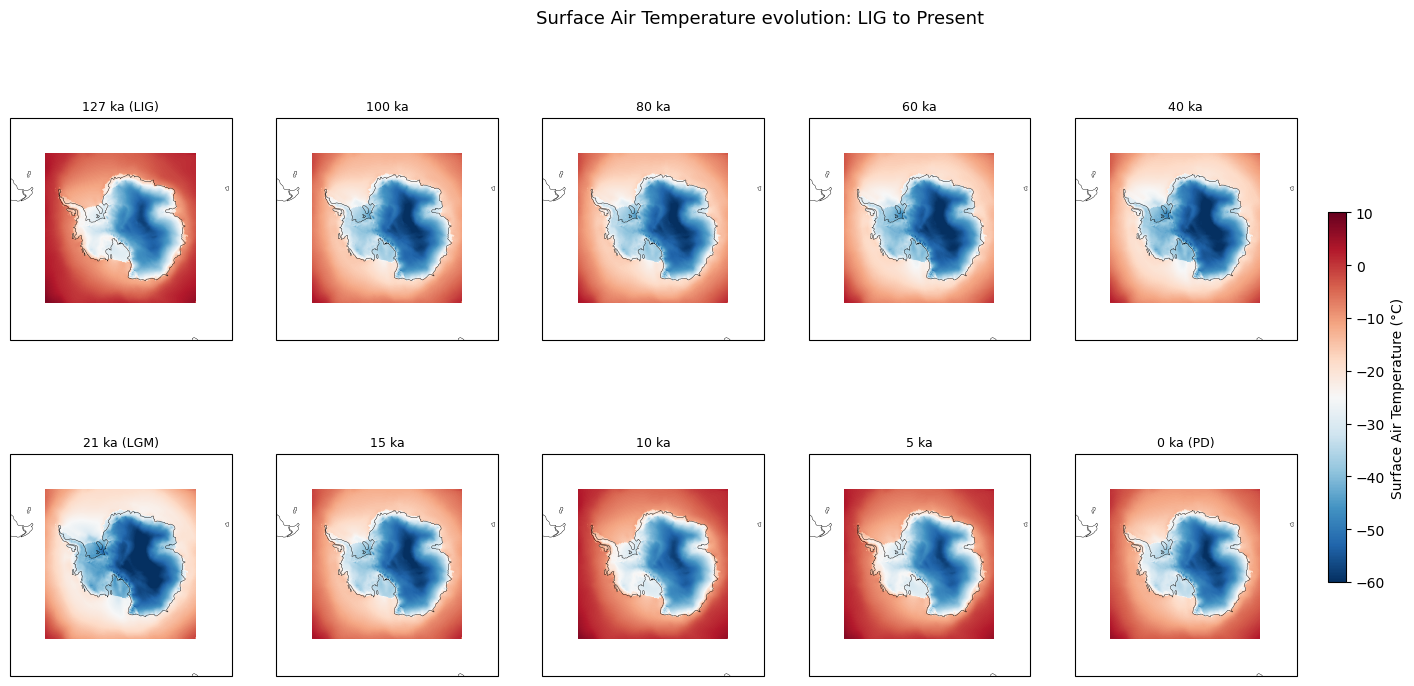

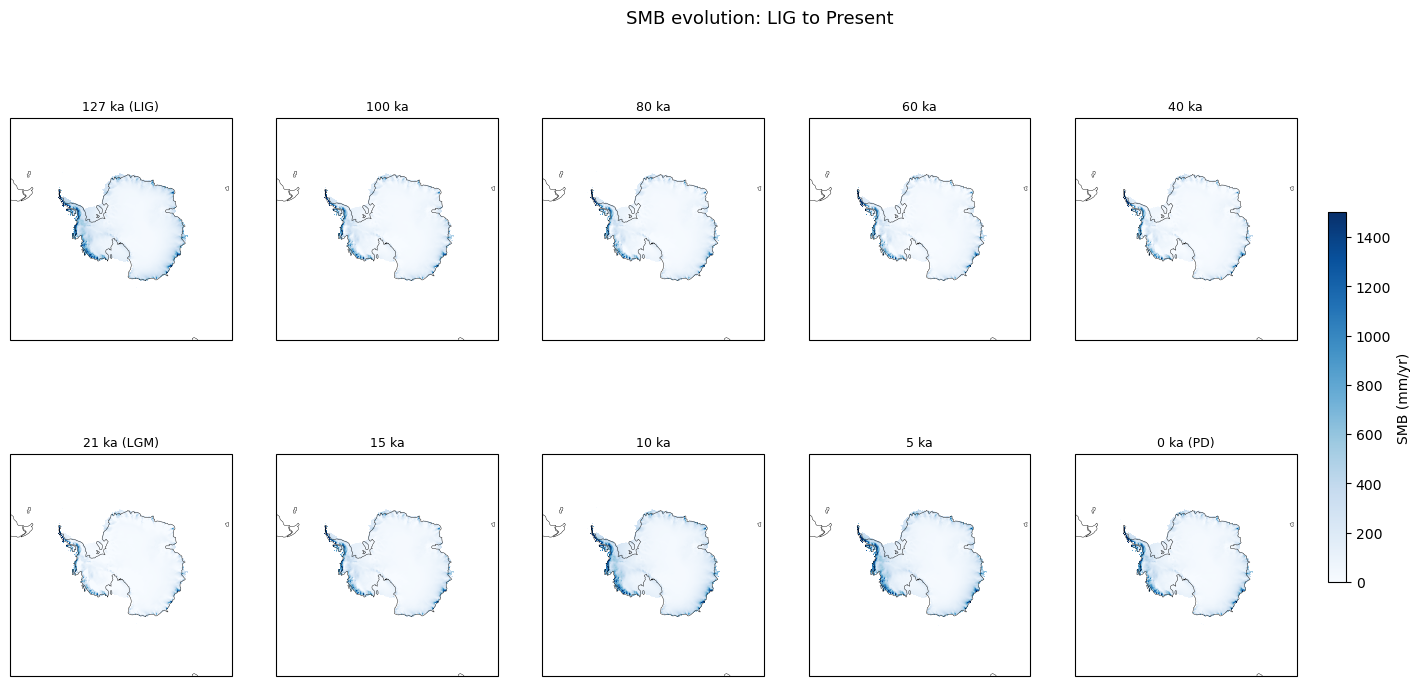

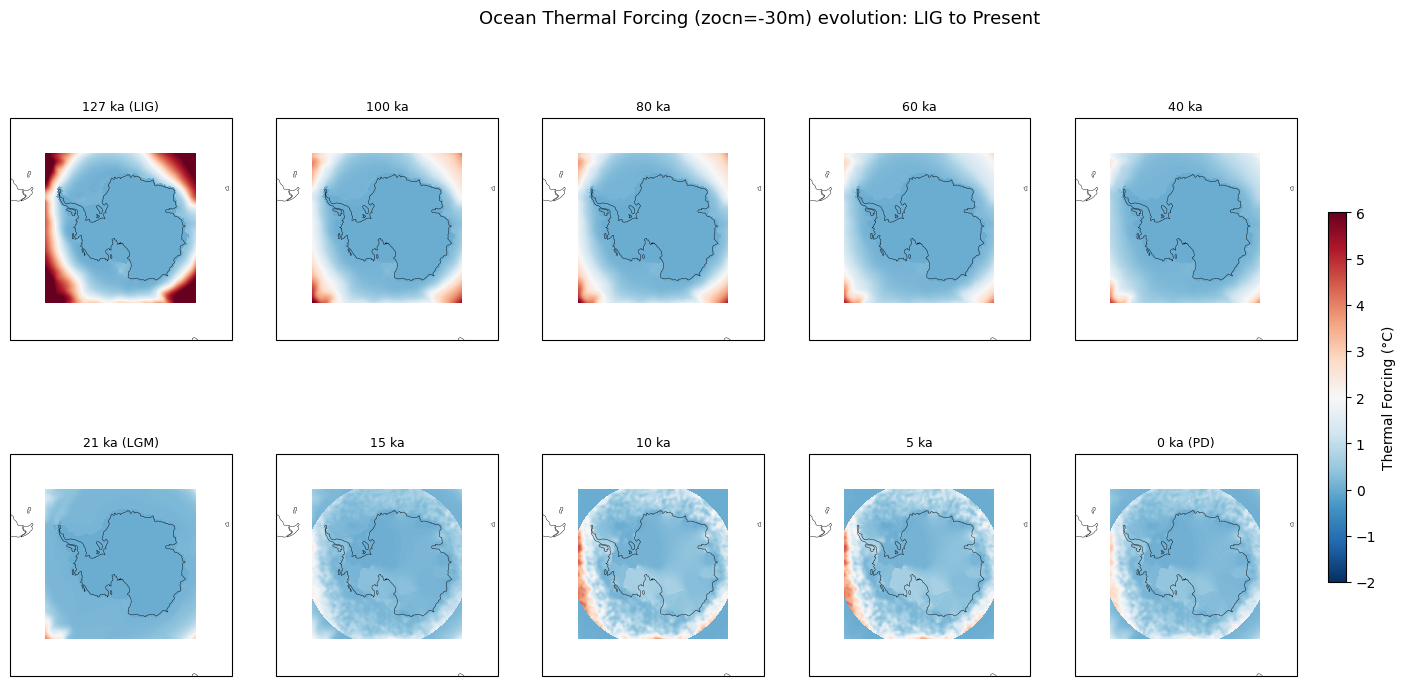

In [19]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

ref_pd = xr.open_dataset("/glade/campaign/cesm/development/liwg/forAdvik/CISM3_initialization_AIS_08000.b_h_s_interp_median.m1for0bed.2025-03-03.nc", decode_cf=False)
lon2d = ref_pd["Lon1"].isel(time=0).values
lat2d = ref_pd["Lat1"].isel(time=0).values

# Pick a few key time slices to plot
# LIG (127ka), glacial (80ka), LGM (21ka), deglaciation (12ka), present (0ka)
key_ages = [127000, 100000, 80000, 60000, 40000, 21000, 15000, 10000, 5000, 0]
key_labels = ["127 ka (LIG)", "100 ka", "80 ka", "60 ka", "40 ka", 
              "21 ka (LGM)", "15 ka", "10 ka", "5 ka", "0 ka (PD)"]

# Find nearest time slice indices for each key age
key_indices = [np.argmin(np.abs(time_slices - age)) for age in key_ages]

# ── 1. Surface Air Temperature ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(20, 8),
                         subplot_kw={"projection": ccrs.SouthPolarStereo()})

for ax, idx, label in zip(axes.flat, key_indices, key_labels):
    ax.set_extent([-180, 180, -90, -50], ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.3)
    p = ax.pcolormesh(lon2d, lat2d, artm_out[idx],
                      transform=ccrs.PlateCarree(),
                      cmap="RdBu_r", vmin=-60, vmax=10)
    ax.set_title(label, fontsize=9)

plt.colorbar(p, ax=axes, label="Surface Air Temperature (°C)", shrink=0.5)
plt.suptitle("Surface Air Temperature evolution: LIG to Present", fontsize=13)
plt.tight_layout()
plt.show()

# ── 2. SMB ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(20, 8),
                         subplot_kw={"projection": ccrs.SouthPolarStereo()})

for ax, idx, label in zip(axes.flat, key_indices, key_labels):
    ax.set_extent([-180, 180, -90, -50], ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.3)
    field = np.where(smb_out[idx] == 0, np.nan, smb_out[idx])
    p = ax.pcolormesh(lon2d, lat2d, field,
                      transform=ccrs.PlateCarree(),
                      cmap="Blues", vmin=0, vmax=1500)
    ax.set_title(label, fontsize=9)

plt.colorbar(p, ax=axes, label="SMB (mm/yr)", shrink=0.5)
plt.suptitle("SMB evolution: LIG to Present", fontsize=13)
plt.tight_layout()
plt.show()

# ── 3. Thermal Forcing at zocn=-30m ─────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(20, 8),
                         subplot_kw={"projection": ccrs.SouthPolarStereo()})

for ax, idx, label in zip(axes.flat, key_indices, key_labels):
    ax.set_extent([-180, 180, -90, -50], ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.3)
    p = ax.pcolormesh(lon2d, lat2d, tf_out[idx, 0],
                      transform=ccrs.PlateCarree(),
                      cmap="RdBu_r", vmin=-2, vmax=6)
    ax.set_title(label, fontsize=9)

plt.colorbar(p, ax=axes, label="Thermal Forcing (°C)", shrink=0.5)
plt.suptitle("Ocean Thermal Forcing (zocn=-30m) evolution: LIG to Present", fontsize=13)
plt.tight_layout()
plt.show()

# ── 4. Time series of domain-mean values ────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Mean over ice sheet only (non-zero SMB cells as proxy)
ice_mask = smb_out[key_indices[-1]] != 0  # use PD as mask

ages_ka = time_slices / 1000

axes[0].plot(ages_ka, [artm_out[i][ice_mask].mean() for i in range(len(time_slices))], 'r-')
axes[0].set_ylabel("Mean artm (°C)")
axes[0].set_title("Domain-mean forcing evolution")
axes[0].invert_xaxis()

axes[1].plot(ages_ka, [smb_out[i][ice_mask].mean() for i in range(len(time_slices))], 'b-')
axes[1].set_ylabel("Mean SMB (mm/yr)")
axes[1].invert_xaxis()

axes[2].plot(ages_ka, [tf_out[i, 0][ice_mask].mean() for i in range(len(time_slices))], 'g-')
axes[2].set_ylabel("Mean TF at -30m (°C)")
axes[2].set_xlabel("Age (ka BP)")
axes[2].invert_xaxis()

plt.tight_layout()
plt.show()

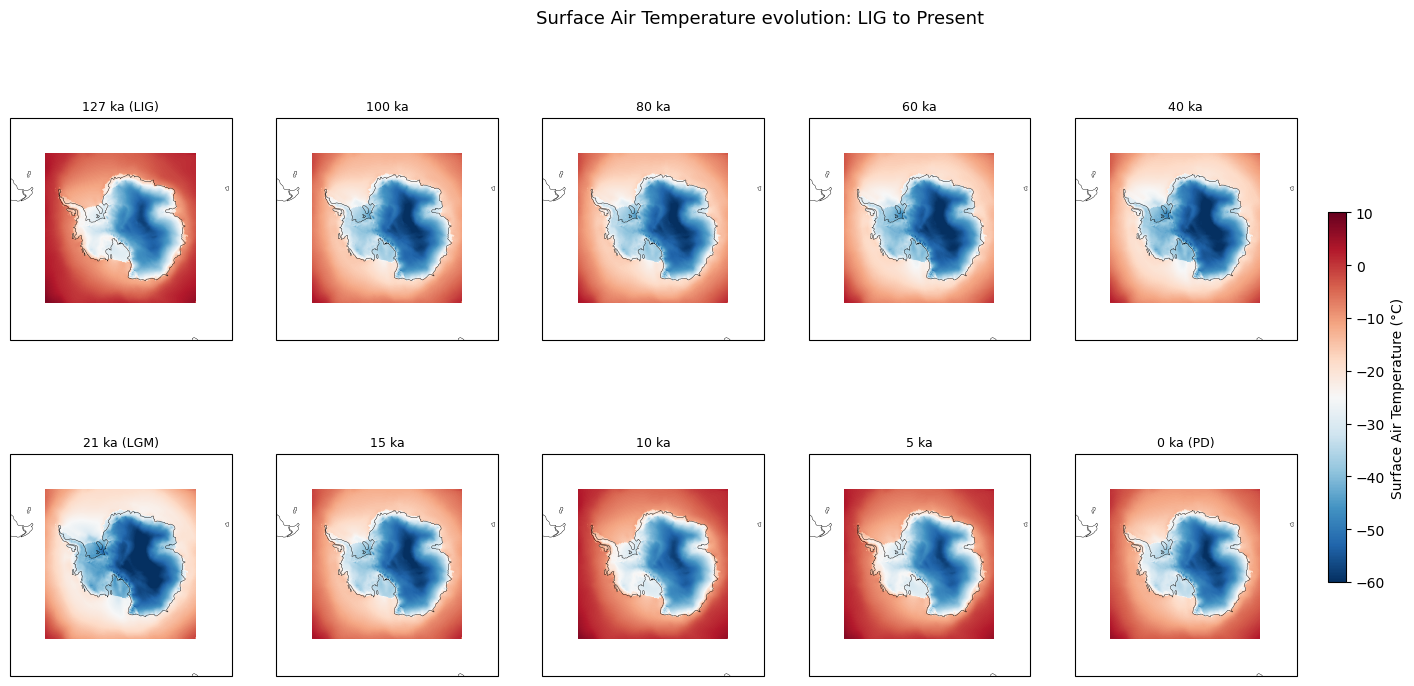

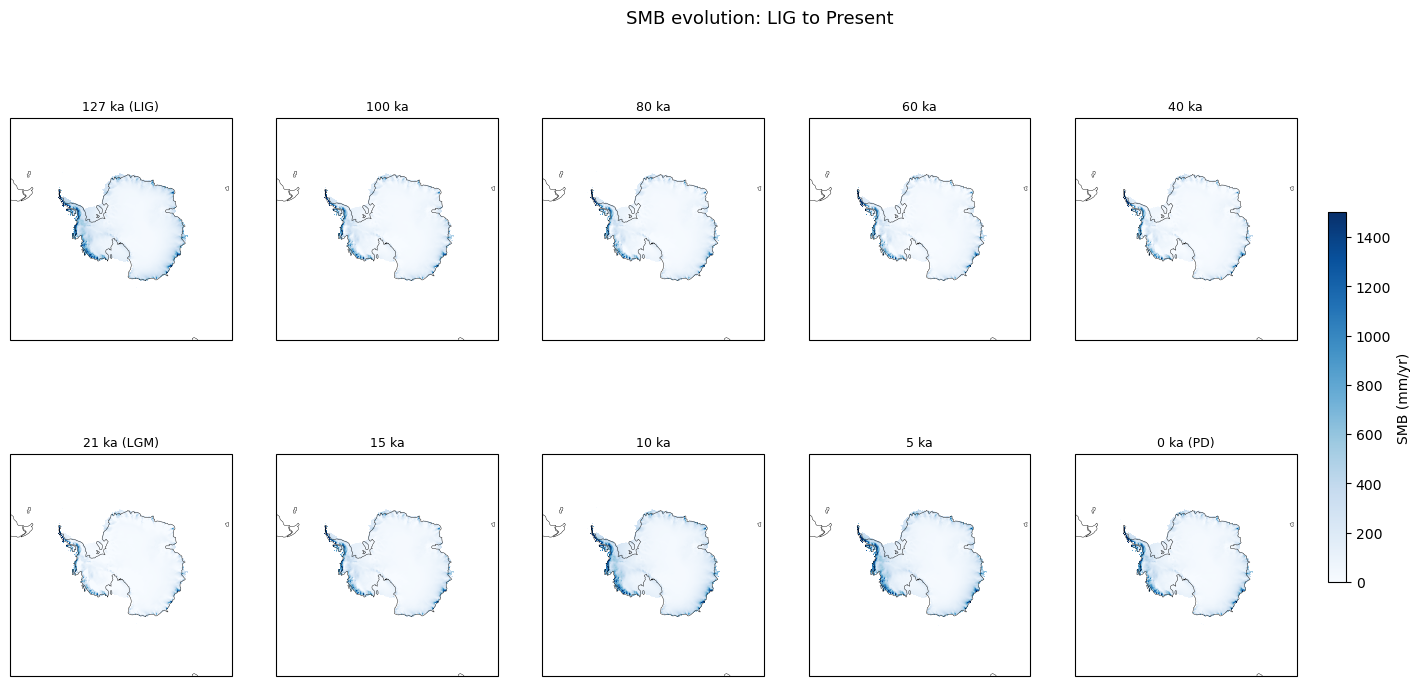

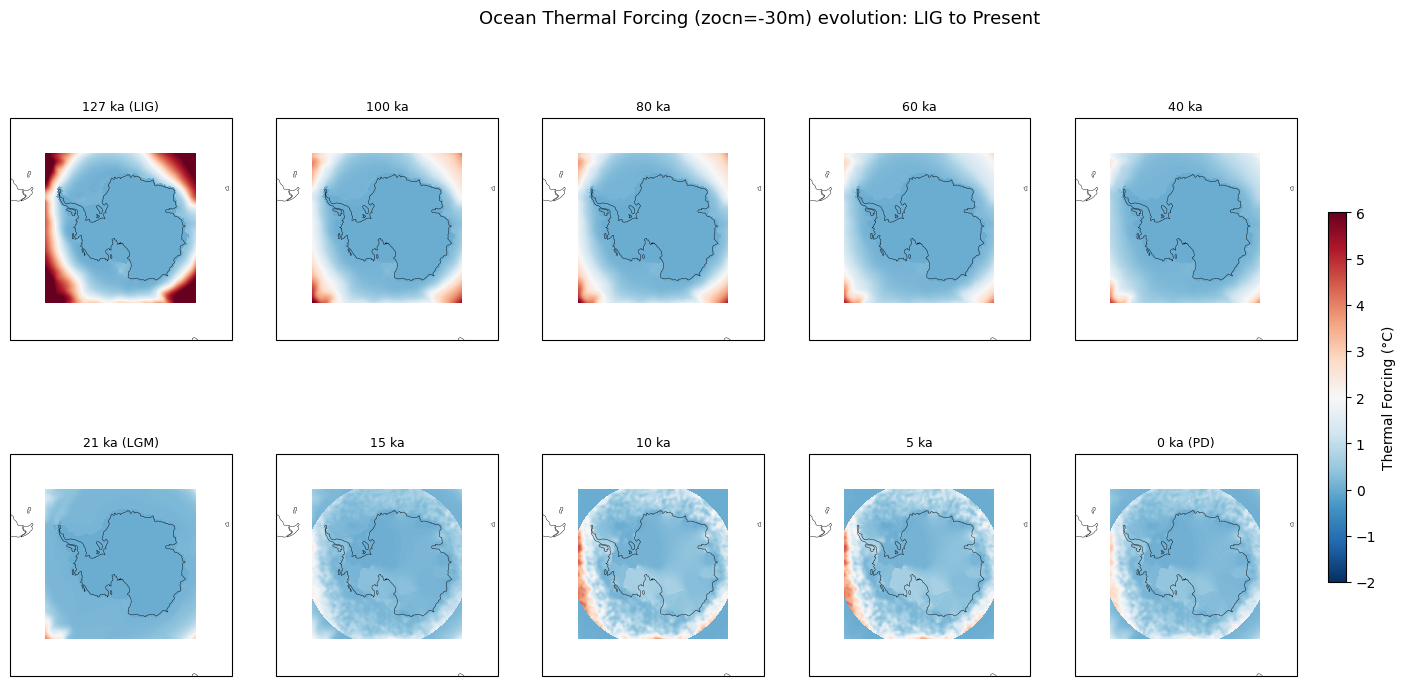

In [20]:
# ── 1. Surface Air Temperature ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(20, 8),
                         subplot_kw={"projection": ccrs.SouthPolarStereo()})

for ax, idx, label in zip(axes.flat, key_indices, key_labels):
    ax.set_extent([-180, 180, -90, -50], ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.3)
    p = ax.pcolormesh(lon2d, lat2d, artm_out[idx],
                      transform=ccrs.PlateCarree(),
                      cmap="RdBu_r", vmin=-60, vmax=10)
    ax.set_title(label, fontsize=9)

fig.colorbar(p, ax=axes.ravel().tolist(), label="Surface Air Temperature (°C)", 
             shrink=0.6, pad=0.02)
plt.suptitle("Surface Air Temperature evolution: LIG to Present", fontsize=13)
plt.savefig("forcing_evolution_artm.png", dpi=150)
plt.show()

# ── 2. SMB ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(20, 8),
                         subplot_kw={"projection": ccrs.SouthPolarStereo()})

for ax, idx, label in zip(axes.flat, key_indices, key_labels):
    ax.set_extent([-180, 180, -90, -50], ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.3)
    field = np.where(smb_out[idx] == 0, np.nan, smb_out[idx])
    p = ax.pcolormesh(lon2d, lat2d, field,
                      transform=ccrs.PlateCarree(),
                      cmap="Blues", vmin=0, vmax=1500)
    ax.set_title(label, fontsize=9)

fig.colorbar(p, ax=axes.ravel().tolist(), label="SMB (mm/yr)",
             shrink=0.6, pad=0.02)
plt.suptitle("SMB evolution: LIG to Present", fontsize=13)
plt.savefig("forcing_evolution_smb.png", dpi=150)
plt.show()

# ── 3. Thermal Forcing ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(20, 8),
                         subplot_kw={"projection": ccrs.SouthPolarStereo()})

for ax, idx, label in zip(axes.flat, key_indices, key_labels):
    ax.set_extent([-180, 180, -90, -50], ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.3)
    p = ax.pcolormesh(lon2d, lat2d, tf_out[idx, 0],
                      transform=ccrs.PlateCarree(),
                      cmap="RdBu_r", vmin=-2, vmax=6)
    ax.set_title(label, fontsize=9)

fig.colorbar(p, ax=axes.ravel().tolist(), label="Thermal Forcing (°C)",
             shrink=0.6, pad=0.02)
plt.suptitle("Ocean Thermal Forcing (zocn=-30m) evolution: LIG to Present", fontsize=13)
plt.savefig("forcing_evolution_tf.png", dpi=150)
plt.show()

In [21]:
# Check SMB values in the interior
print("SMB stats at 21ka (LGM):")
smb_lgm = smb_out[np.argmin(np.abs(time_slices - 21000))]
print(f"  All cells - min: {smb_lgm.min():.3f}, max: {smb_lgm.max():.3f}, mean: {smb_lgm.mean():.3f}")
print(f"  Non-zero cells: {(smb_lgm != 0).sum()}")
print(f"  Zero cells: {(smb_lgm == 0).sum()}")
print(f"  Cells between 0 and 100 mm/yr: {((smb_lgm > 0) & (smb_lgm < 100)).sum()}")
print(f"  Cells between 100 and 500 mm/yr: {((smb_lgm >= 100) & (smb_lgm < 500)).sum()}")

# Check a specific interior point - roughly center of East Antarctica
print(f"\nSMB at East Antarctic interior (~center of grid):")
print(f"  smb_lgm[380, 380] = {smb_lgm[380, 380]:.3f}")
print(f"  smb_lgm[400, 400] = {smb_lgm[400, 400]:.3f}")

SMB stats at 21ka (LGM):
  All cells - min: -574.835, max: 4521.966, mean: 26.786
  Non-zero cells: 212431
  Zero cells: 366690
  Cells between 0 and 100 mm/yr: 146168
  Cells between 100 and 500 mm/yr: 30188

SMB at East Antarctic interior (~center of grid):
  smb_lgm[380, 380] = 40.863
  smb_lgm[400, 400] = 27.200
